# Netrunner Agenda Points Analysis

In [1]:
# Imports

import pandas as pd
import main as m
import regex as re
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import warnings
warnings.filterwarnings('ignore')

import notebook_companion as nc

## Wrangle

### Analysis Methodology

* Develop a possibility matrix for all legal combinations of minimum deck size, use of the four card margin, agenda point total, and distribution of 1, 2, and 3 point agendas for corporation decks
* Each feature is represented as a column in a dataframe and each row represents one unique combination of these features
* Add a additional rows to the matrix by replacing the maximum number of normal two-point agendas with Let Them Dream agendas 
* Calculate access threshold for each row using digital experiments
* Examine how different feature values shift the possibility matrix to determine the effect of those features on access threshold 

### Methodology of Digital Experiments to Determine Access Threshold

* Access threshold is the average number of unique random accesses a runner needs to steal 7 points worth of agendas and win the game
* The access threshold of each combination of features or row was calculated using the following method
    * Represent the corporation's deck by making a list containing a number of values equal to the testing deck’s deck size
        *  Values in the list represent the agenda point values of the agendas in the deck
            *  Mostly zeros with a number of one, two, and three values equal to the number of one, two, and three point agendas in the deck
    * Simulate a random access by choosing a value at random from the list and adding that value to the runners total score
    * Simulate the accessed card being stolen, trashed (discarded from play), or otherwise avoided by removing that card from the list
    * Continue simulating random accesses until the runner has a score of 7 or more and count the number of accesses it took to reach this total
    * To ensure a large sample size and reduce statistical error repeat the experiment 100,000 times and get the average result
    * Round result to the nearest whole number for ease of discussion and communicability of result

### Let Them Dream Methodology

* Let Them Dream is a two-point agenda with an ability that reduces its vale by 1 if it is in the runner's score area effectively making it a two-point agenda for the corporation and a one-point agenda for the runner
* To measure the impact of Let Them Dream agendas on access threshold additional rows were added to simulate replacing ‘normal’ two-point agendas with maximum allowable number of ‘Let Them Dream’ agendas
    * For each row with one or more two-point agendas an additional row was added replacing up to a maximum of three two-point agendas with Let Them Dream Agendas
    * A maximum of 3 replacements are made because the maximum number of card copies (by title) that can be included in a deck is 3
    * A replacement is simulated by lowering the number of two-point agendas by one and increasing the number of one-point agendas by one
    * This effectively counts the agenda as being worth 2 points for agenda point total and 1 point if the runner steals the agenda
    <br>
* **Limitation**
    * This matrix only includes possibilities replacing the maximum number normal two-point agendas
        * It does not account for replacing less than the maximum (Example has 2 two-point agendas but only replaces one)
        * It does not account for replacements swapping 2 one-point agendas for 1 Let Them Dream
        * It does now account for replacements swapping 1 three-point agenda for 1 one-point agenda and 1 Let Them Dream
        * This limitation is largely due to oversight and will be corrected if I should return to this project for future iterations

### Final Dataframe
* 8 columns and 928 total rows
    * Each column representing a feature of the deck
    * 496 rows representing all legal combinations of deck features
    * 432 rows that simulate replacing ‘normal’ two-point agendas with maximum allowable number of ‘Let Them Dream’ agendas

### Data Dictionary

|Feature|Definition|
|---|---|
|deck_size| Total number of cards |
|agenda_points| Total value of all agenda points on agendas |
|agenda_count| Number of agendas in this build |
|one_point_agendas| Number of agendas with a value of 1 |
|two_point_agendas| Number of agendas with a value of 2 |
|three_point_agendas| Number of agendas with a value of 3 |
|ltd_count| Number of "Let Them Dream" agendas |
|access_threshold| Average number of unique cards a runner must access win the game |

In [3]:
# read in data
df, df_normal, df_ltd = nc.get_my_data()

## Data Exploration

### Overview of Access Threshold 

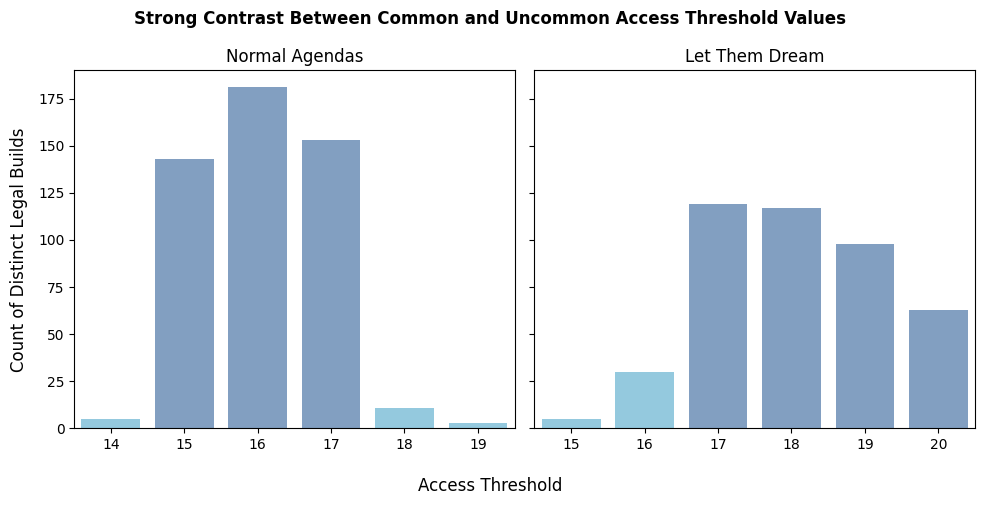

In [4]:
# get build count by access threshold chart
nc.get_my_thresholds(df_normal, df_ltd)

* The grand majority of normal agenda builds have an access threshold that ranges between 15 and 17 indicating that values outside the of majority range will only occur under precise conditions
* The grand majority of Let Them Dream builds have an access threshold between 17 and 20
indicating that values lower than the majority range will only occur under precise conditions
* The shift in majority range from 15-17 in normal builds to 17-20 in Let Them Dream builds indicates that replacing normal two-point agendas with Let Them Dream agendas could increase access threshold by 2-3 accesses

### What is the Effect of Agenda Density on Access Thereshold?
* In this study I define agenda density as the number of agenda points in a build relative to the total number of cards in that build
* I have calculated agenda density by dividing the number of agenda points in each build by the total number of cards in that build

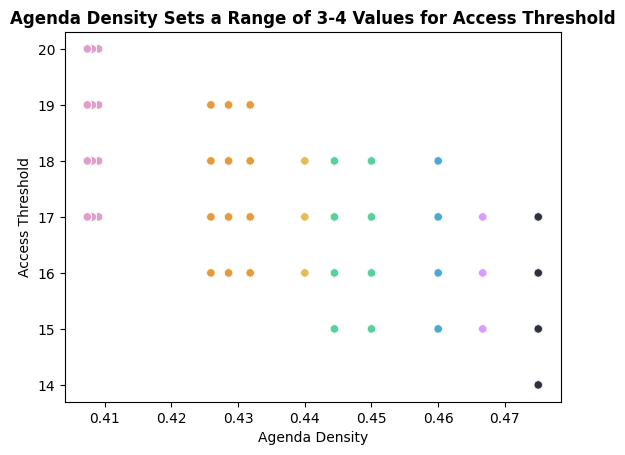

In [5]:
# get agenda density chart
nc.get_my_density_chart(df)

* Agenda density has a negative relationship with access threshold setting a range of 3-4 possible values

### What is the Effect of Deck Size on Access Threshold?

### Minimum Deck Size

* The minimun deck size for a corporation deck is 40, 45, or 50 depending on the identity card chosen for the build

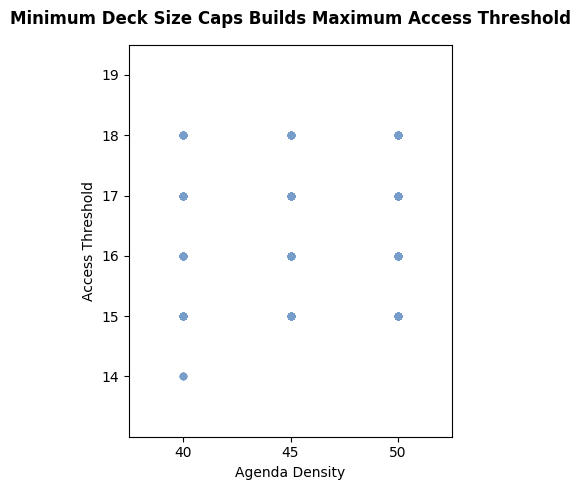

In [6]:
# get minimum deck size chart
nc.get_min_deck_chart(df)

* Decks using the minimum deck size have a maximum access threshold of 18
* There is a negligible difference in access threshold between minimum deck sizes
    * The possibility of a particularly low access threshold does exist when using a 40 card build

### 4 Card Margin
* Corporation decks are required to include a number of agenda points based on total number of cards in the deck
* The agenda point requirement increases with every 5th card added
* For that reason it is conventional wisdom to build corporation decks 4 cards over the minimum to reduce agenda density
* I call this the 4 card margin

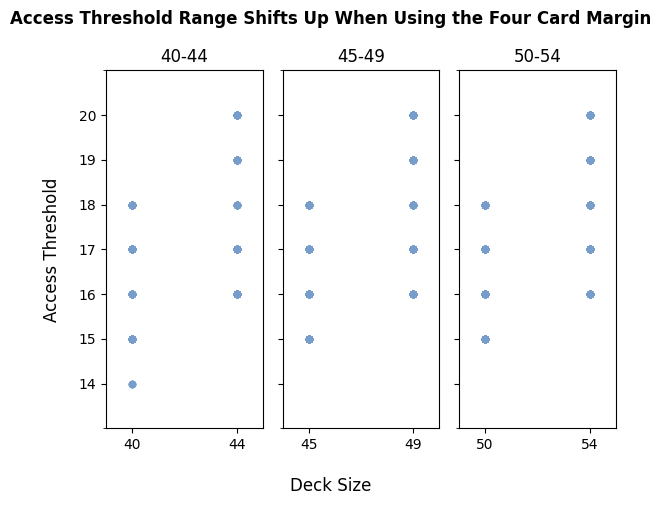

In [7]:
# get 4 card margin chart
nc.get_margin_chart(df)

* Based on the shift in the access threshold range using the four card margin will raise a build's access threshold by 1-2 accesses

## What is the Effect of Agenda Point Total on Access Threshold?

* Corporation decks are required to include a number of agenda points based on total number of cards in the deck and can include one extra agenda point if desiered
* It is conventional wisdom to include only the minimum number of agenda points to reduce agenda density

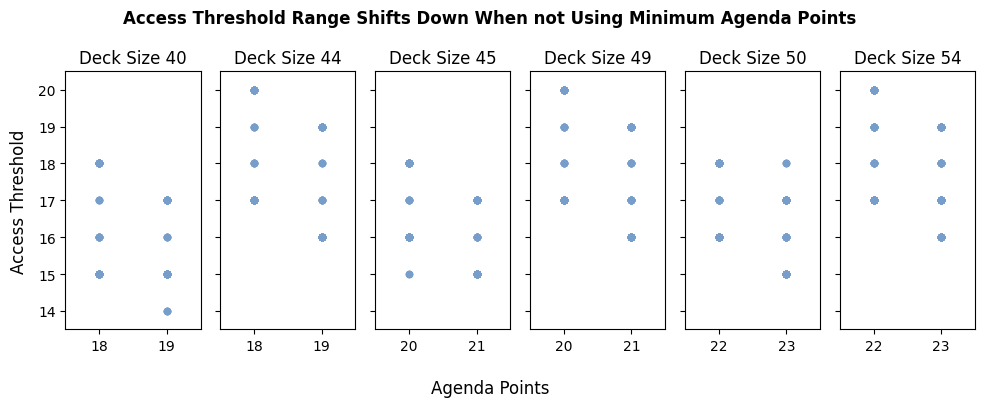

In [8]:
# get agenda point chart
nc.get_my_min_agenda_chart(df)

* The shift in the access threshold range indicates that builds using the minimum number of agenda points have an access threshold that is about 1 access higher than builds that include an extra agenda point

## Agenda Density Summary

**Overall Agenda Density**
* Agenda density has a negative relationship with access threshold setting a range of 3-4 possible values

**Deck Size**
* Decks using the minimum deck size have a maximum access threshold of 18
* Minimum deck size has negligible impact on Access threshold
* Use of the 4 card margin will increase access threshold by about 1-2 accesses

**Agenda Points**
* Builds using the minimum number of agenda points have an access threshold that is about 1 access higher than builds that include an extra agenda point

## Agenda Concentration

* In this study I define agenda concentration as the degree to which agenda points are concentrated in high point cards or spread out in lower point cards
    * For example a deck with one three-point agenda has a higher concentration of agenda points that a deck with three one-point agendas even though the total number of agenda points is the same

**Looking at Normal Agendas**
* The deck-building flexibility given by Let Them Dream's ability to modify its agenda values creates too much noise in possibility matrix to get a clear signal
* In this section we will be looking at builds that do not include Let Them Dream

### What is the Effect of Agenda Count on Access Threshold?

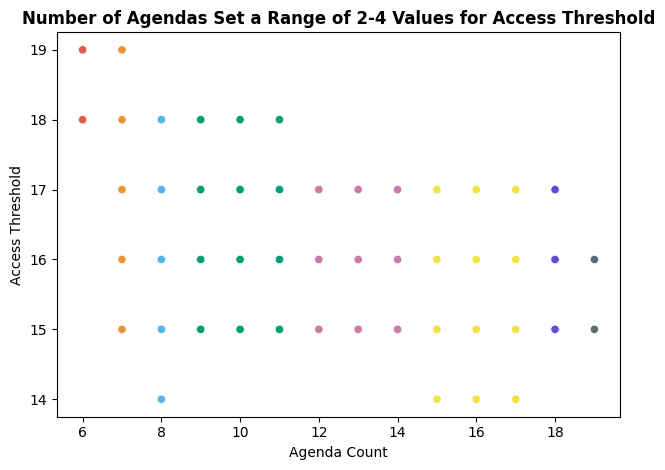

In [9]:
nc.get_my_agenda_count_chart(df_normal)

* There is a negative relationship between number of agendas and access threshold setting a range of 2-4 values 
* The Number of agendas in a build set a range of possible Access threshold values
    * That range reduces from 3-4 values to only 2 at extreme values indicating that the number of agendas is more impactful at extreme values

### What is the Effect of Three-Point Agenda Count on Agenda Threshold?

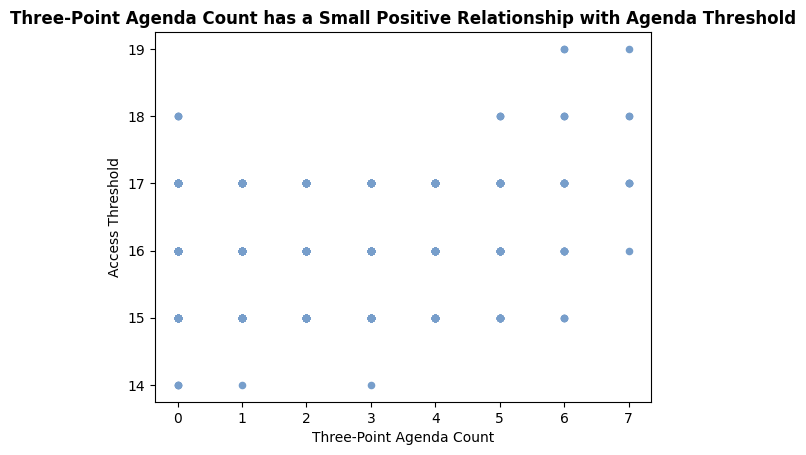

In [10]:
nc.get_my_threes_chart(df_normal)

* There is a small positive relationship between three-point agenda count and access threshold
    * At extreme values there is a potential for access thresholds above or below the majority range (15-17)
        * The large range of possible access thresholds (4-5 out of 6 possible values) even at extreme values suggest that the influance of three-point agenda count is not very strong

#### Outlier Builds

* The builds with zero three-point agendas and an access threshold of 18 stood out as outliers

In [11]:
df_example = nc.get_my_first_outlier_df(df_normal)
df_example

,agenda_type,deck_size,agenda_points,three_point_agendas,two_point_agendas,one_point_agendas,access_threshold
186,Normal,44,18,0,9,0,18
501,Normal,49,20,0,10,0,18
858,Normal,54,22,0,11,0,18


* All of these builds used the 4 card margin, lowest agenda point total, and had only two-point agendas (the lowest possible agenda density and concentration outside of using three-point agendas)
* Stacking these other advantages gave an above average access threshold while not using three-point agendas

### What is the Effect of One-Point Agenda Count on Agenda Threshold?

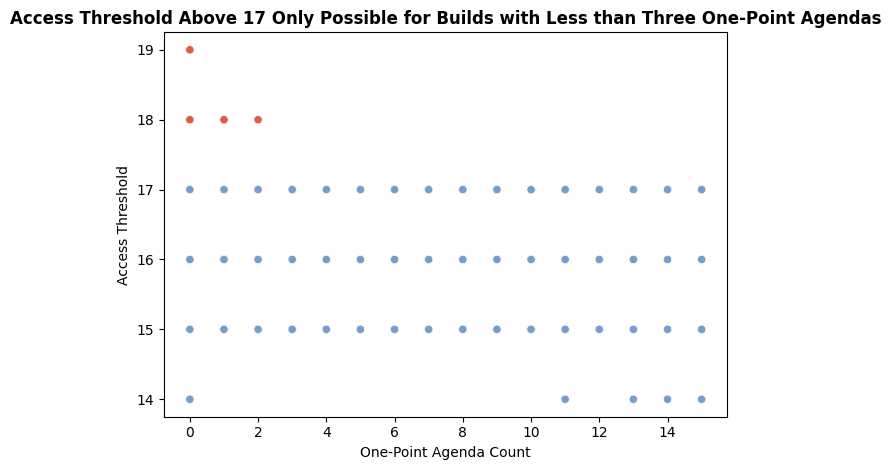

In [12]:
nc.get_my_ones_chart(df_normal)

* There is a small negative relationship between one-point agenda count and access threshold
    * At extreme values there is a potential for access thresholds above or below the majority range (15-17)
        * The large range of possible access thresholds (4-5 out of 6 possible values) even at extreme values suggest that the influance of one-point agenda count is generally not very strong
        * Builds containing 3 or more one-point agendas cannot have an access threshold higher than 17

**Outlier Builds**
* The build with 0 one-point agendas and an access threshold of 14 stood out as an outlier (There is only one build that meets this criteria) 
    * This build contains the minimum possible deck size and uses the highest agenda point total for its deck size, giving is the highest possible agenda density in the game
    * This is why it has a very low access threshold while not using any one-point agendas

In [13]:
nc.get_my_second_outlier_df(df)

,agenda_type,deck_size,agenda_points,one_point_agendas,two_point_agendas,three_point_agendas,access_threshold
135,Normal,40,19,0,5,3,14


## Agenda Concentration Summary

* Agenda count (Normal) has a large degree of veriability at thresholds 15-17, at more extreme values we see a negative relationship between agenda count and access threshold with clear cutoff points for agenda count allowable to produce a given access threshold

* Three-point agenda count (Normal) has a large degree of veriability at thresholds 15-17, at more extreme values we see a positive relationship between Three-point agenda count and access threshold with clear cutoff points for the required three-point agenda count needed to produce a given access threshold

* One-point agenda count (Normal) has a large degree of veriability at thresholds 15-17, at more extreme values we see a negative relationship between agenda count and access threshold with clear cutoff points for agenda count allowable to produce an access thresholds above 17


In [14]:
df_normal['is'] = df.agenda_counts == '[3, 5, 0]'

In [15]:
df_normal[df.agenda_counts == '[3, 5, 0]']

,agenda_type,deck_size,agenda_points,ltd_count,agenda_counts,agenda_count,access_threshold,three_point_agendas,two_point_agendas,one_point_agendas,calc_agenda_points,agenda_density,is
135,Normal,40,19,0,"[3, 5, 0]",8,14,3,5,0,19,0.475000,True
279,Normal,44,19,0,"[3, 5, 0]",8,16,3,5,0,19,0.431818,True


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 928 entries, 0 to 991
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   agenda_type          928 non-null    object 
 1   deck_size            928 non-null    int64  
 2   agenda_points        928 non-null    int64  
 3   ltd_count            928 non-null    int64  
 4   agenda_counts        928 non-null    object 
 5   agenda_count         928 non-null    int64  
 6   access_threshold     928 non-null    int64  
 7   three_point_agendas  928 non-null    int64  
 8   two_point_agendas    928 non-null    int64  
 9   one_point_agendas    928 non-null    int64  
 10  calc_agenda_points   928 non-null    int64  
 11  agenda_density       928 non-null    float64
dtypes: float64(1), int64(9), object(2)
memory usage: 126.5+ KB


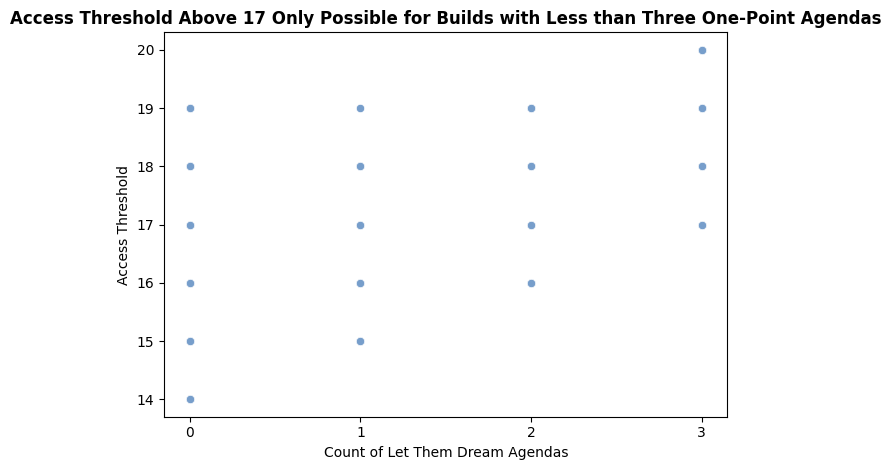

In [17]:
nc.get_my_ltd_data(df)

* Replacing one or two normal agendas with Let Them Dream agendas will increase the access threshold by about 1 point each capping at 19
* Replacing a third normal agenda will increase the access threshold by 1
* This shows about a one point increse in access threshold per Let Them Dream in the Corp Deck

## Let Them Dream

* Replacing a normal two-point agenda with a Let Them Dream agenda will raise a build’s access threshold by about 1 per agenda replaced. This is likely due to lowering the total number of agenda points the runner can steal by 1 per replaced agenda. 


## Summary and Conclusions

* Access thresholds across all possible builds have a range of 14 to 20 meaning that deck building decisions have a 6 access influence on access threshold
* Minimum deck size has a negligible effect on access threshold, however Including the 4 card in the margin between an IDs minimum deck size and the size at which the corp’s required agenda point total would increase increases access threshold by 1-2 accesses 
* Access thresholds in builds using the minimum agenda point total for its deck size are 1 access higher than builds using the maximum   
* Agenda density has a negative influence on access threshold
* Builds with a higher concentration of agenda points have a higher access thresholds
* Builds that include Let Them Dream agendas have access thresholds that are about 1 access higher for every normal two-point agenda replaced by a let them dream
* It occurs to me that I did not account for situations in which pairs of one point agendas are replaced by one let them dream agenda or situations in which one three point agenda is replaced by a one-point agenda and a Let Them Dream Agenda
    * In the former case I estimate a 1-2 access increase in access threshold, per replacement, due to the increase in agenda concentration (Two agendas replaced by one) and lowering of the stealable agenda point total by one. 
    * In the latter I estimate a 0-1 access increase in access threshold, per replacement,  due to the the decreases agenda concentration (one agenda swapping for two) mitigating the impact of lowering stealable agenda point total by one


## Recommendations

* Always use the four card margin, The increased access threshold as well as the resources granted by those four cards will outweigh the loss in consistency caused by the addition of those four cards
* Almost always build to the minimum number of agenda points for your deck size this will increase you access threshold by one, so do this unless you need access to a specific card and cannot otherwise fit it into your build
* Strongly consider using higher value agenda cards for your build. Your first priority in deck building should be deck synergy (how well the abilities on your cards work together). However, if you find that multiple agenda cards work just as well prioritise agendas with higher values
* Strongly consider using Let Them Dream agendas in your build. The major benefit to this card is that it lowers the number of agenda points the runner can steal by 1 per inclusion increasing a deck’s access threshold by 1-2 accesses per card included (depending on what’s being replaced). This combined with the agenda management included in its card ability makes it an auto include in builds that can cover the inv=fluance cost and don’t require an agenda suite that prohibits its use. 
